   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

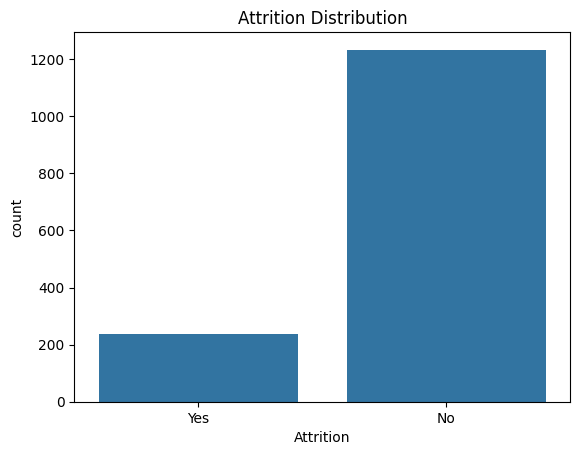

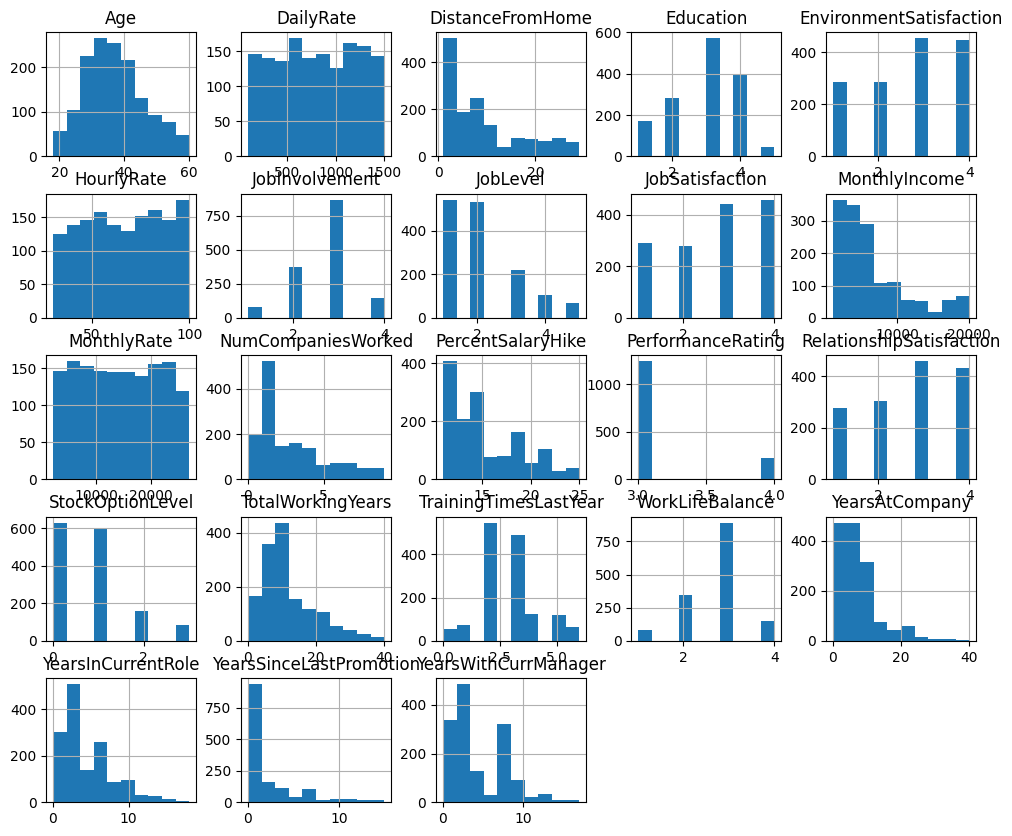

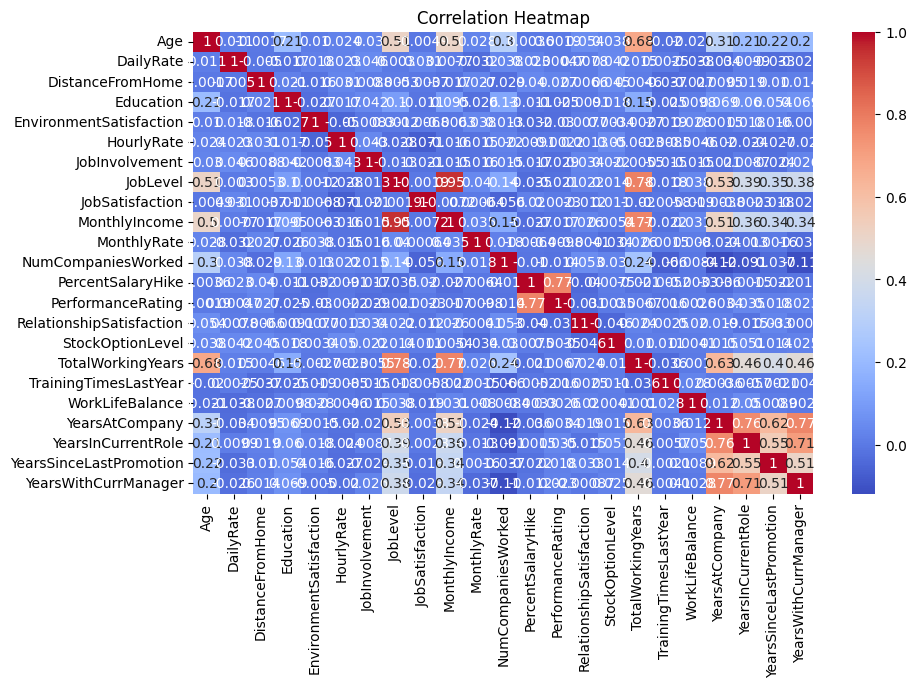

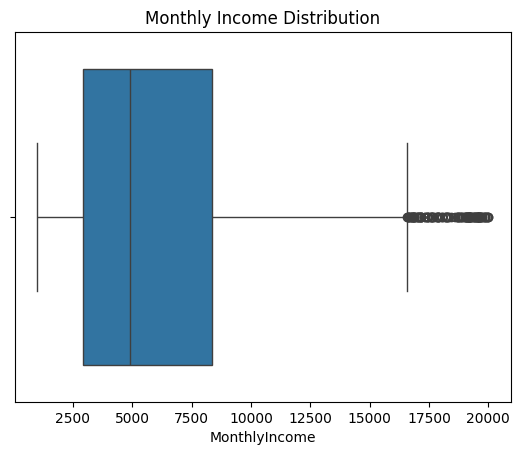

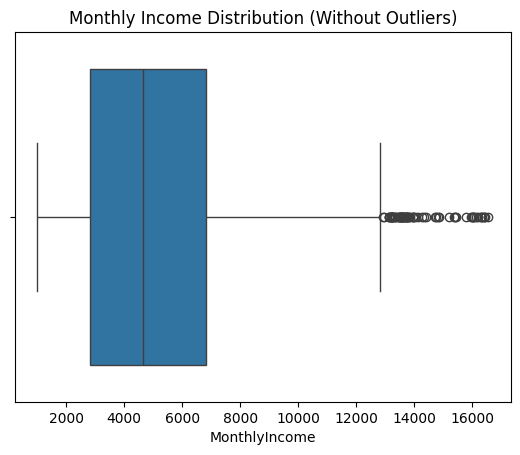

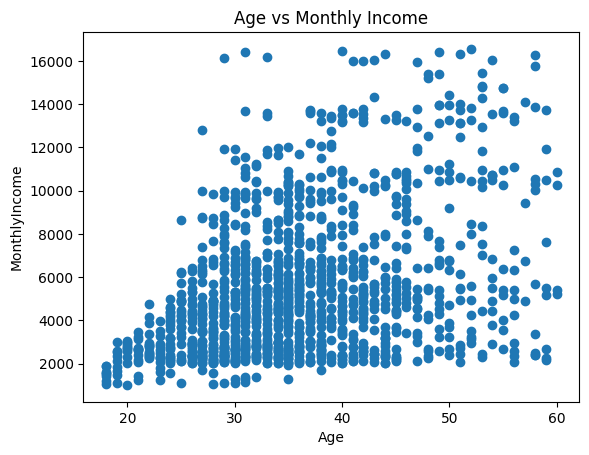

Logistic Regression Accuracy: 90.07352941176471


C:\Users\gnana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12844 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df = pd.read_csv("employee.csv.csv")

print(df.head())
df.describe()
df.isnull().sum()
df = df.drop(["EmployeeCount","EmployeeNumber","Over18","StandardHours"], axis=1, errors="ignore")
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Distribution")
plt.show()
df.hist(figsize=(12,10))
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
sns.boxplot(x=df["MonthlyIncome"])
plt.title("Monthly Income Distribution")
plt.show()
Q1 = df["MonthlyIncome"].quantile(0.25)
Q3 = df["MonthlyIncome"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["MonthlyIncome"] >= lower) & (df["MonthlyIncome"] <= upper)]
df_no_outliers = df[(df["MonthlyIncome"] >= lower) & (df["MonthlyIncome"] <= upper)]
sns.boxplot(x=df_no_outliers["MonthlyIncome"])
plt.title("Monthly Income Distribution (Without Outliers)")
plt.show()
plt.scatter(df["Age"], df["MonthlyIncome"])
plt.xlabel("Age")
plt.ylabel("MonthlyIncome")
plt.title("Age vs Monthly Income")
plt.show()
df = pd.get_dummies(df, drop_first=True)
X = df.drop("Attrition_Yes", axis=1)
y = df["Attrition_Yes"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=20000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy * 100)